In [1]:
import pandas as pd
from pathlib import Path

from src import ASCAT_ERA5_data_cleaning as utils
from src.general_data_cleaning_utils import plot, validate_time_index, validate_data_cleaning_input, filter_df
from src import constants as c

# Data Understanding and Preparation of the ASCAT and ERA5 Data

The goal is to generate descriptive statistics, drop missing values & outliers, and plot the data for all ASCAT and ERA5 data in `data/raw/ASCAT` and `data/raw/ERA`. The cleaned data will then be exported to their respective folders in `data/cleaned`.

---

### Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *3.5 L23*
    - *3.6 L38*
    - *3.7 NST-07*
    - *3.8 NST-09*
    - *3.9 SOD012*
    - *3.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [2]:
# key columns
ASCAT_short_var_name = 'backscatter40'
ERA5_short_var_name = 'stl1'
ASCAT_long_var_name = '40° Normalized Backscatter (dB)'
ERA5_long_var_name = 'Soil Temperature Level 1 (C)'

# path variables
ASCAT = 'ASCAT'
ERA5 = 'ERA5'
raw_path = Path('../data/raw/ASCAT_ERA5')
cleaned_path = Path('../data/cleaned')
Path(cleaned_path / ASCAT).mkdir(parents=True, exist_ok=True)
Path(cleaned_path / ERA5).mkdir(parents=True, exist_ok=True)

### 1.2 Functions

In [3]:
def data_cleaning(data_path: Path, ismn_sites_path: Path,
                  station: str, system: str, key_variable: str,
                  date_range=None) -> pd.DataFrame:
    """
    Preprocessing of raw ASCAT or ERA5 data.
    :param data_path: path to csv file
    :param ismn_sites_path: path to csv file containing ISMN site information
    :param station: must match exactly name in ISMN_site_survey.csv
    :param system: ASCAT or ERA5, case-insensitive
    :param key_variable: name of variable of interest (in csv)
    :param date_range: list of datetime objects. Data outside this range is filtered out. Min is inclusive and max is exclusive. Assumed that input is in the same timezone as df.index. If date_range is not valid for given df, date_range will be adjusted to be valid.
    :return: cleaned dataframe
    """
    # validate inputs
    validate_data_cleaning_input(data_path, date_range)

    df = utils.collect_data(data_path, ismn_sites_path, station, system)
    utils.check_df_cols(df, system)

    # report NaN count and proportion
    na_count = df.isnull().sum()[key_variable]
    print(f'There are {na_count} nulls out of {len(df)} datapoints ({round(na_count/len(df),2)}% missing).')

    df = df.dropna(subset=[key_variable]) # interpolation not recommended
    df = utils.round_nearest_hour_index(df)
    df = filter_df(df, date_range=date_range)

    return df

def data_reporting(df: pd.DataFrame, variable: str, station_name: str, system: str, ylabel: str) -> None:
    """
    Reporting of preprocessed ASCAT and ERA5 data.
    :param df: can be output from soil_temp_data_cleaning()
    :param variable: full variable name
    :param station_name: official name of ISMN station
    :param system: name of sensor system
    :param ylabel: y-label for plot
    :return:
    """
    # check input values
    if variable not in df.columns:
        raise KeyError(f'df missing required column "{variable}".')
    # check input df index
    validate_time_index(df)

    print('Summary statistics:')
    display(df.describe())
    print('Show head of df:')
    display(df.head())

    plot(df, variable, station=station_name, system=system, form='line', y_label=ylabel)

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

#### ASCAT

In [4]:
ASCAT_Aberdeen_df = data_cleaning(data_path=raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=c.ABERDEEN_NAME,
                                  system=ASCAT,
                                  key_variable=ASCAT_short_var_name,
                                  date_range=c.DATE_RANGE)
ASCAT_Aberdeen_df.head()

There are 1618 nulls out of 17799 datapoints (0.09% missing).


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 04:00:00+00:00,-18.138327,1,0,3
2007-01-02 04:00:00+00:00,-18.249712,1,0,3
2007-01-02 16:00:00+00:00,-18.546434,1,1,3
2007-01-03 17:00:00+00:00,-17.615808,0,1,3
2007-01-04 03:00:00+00:00,-15.992000,0,0,3


In [5]:
ASCAT_Aberdeen_df.describe()

,backscatter40,swath_indicator,as_des_pass,sat_id
count,16181.000000,16181.000000,16181.000000,16181.000000
mean,-14.759586,0.497497,0.490328,3.727458
std,1.715188,0.500009,0.499922,0.751516
min,-19.637800,0.000000,0.000000,3.000000
25%,-15.928318,0.000000,0.000000,3.000000
50%,-14.600672,0.000000,0.000000,4.000000
75%,-13.589661,1.000000,1.000000,4.000000
max,-6.488361,1.000000,1.000000,5.000000


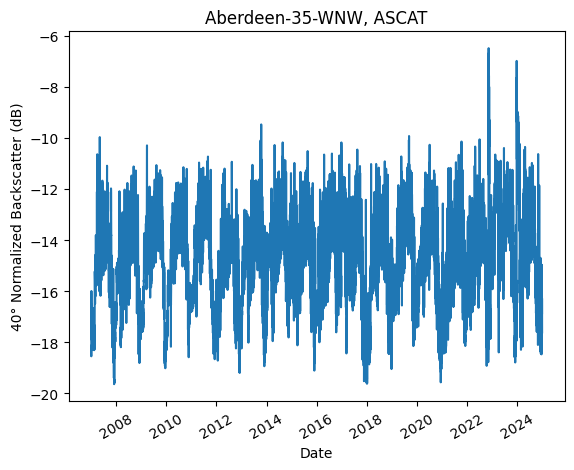

In [6]:
plot(df=ASCAT_Aberdeen_df, variable=ASCAT_short_var_name, y_label=ASCAT_long_var_name,
     station=c.ABERDEEN_NAME, system=ASCAT, form='line')

#### ERA5

In [7]:
ERA5_aberdeen_df = data_cleaning(data_path=raw_path,
                                 ismn_sites_path=c.SITE_SURVEY_PATH,
                                 station=c.ABERDEEN_NAME,
                                 system=ERA5,
                                 key_variable=ERA5_short_var_name,
                                 date_range=c.DATE_RANGE)
ERA5_aberdeen_df.head()

There are 0 nulls out of 27760 datapoints (0.0% missing).


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-8.824951,-3.689606,-1.241242,0.236350,0.243425,0.011896
2007-01-01 06:00:00+00:00,-10.743195,-6.642731,-1.306000,0.236399,0.243433,0.011884
2007-01-01 12:00:00+00:00,-12.849762,-8.534576,-1.427521,0.236382,0.243390,0.011883
2007-01-01 18:00:00+00:00,-6.766449,-4.998962,-1.519897,0.236419,0.243401,0.011862
2007-01-02 00:00:00+00:00,-10.536652,-3.941009,-1.538055,0.236313,0.243309,0.011836


In [8]:
ERA5_aberdeen_df.describe()

,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,6.491117,8.076804,8.347241,0.277745,0.265314,0.007359
std,14.141269,11.086022,10.018990,0.063695,0.057899,0.018629
min,-38.990770,-25.262360,-15.971466,0.130465,0.132934,0.000000
25%,-3.884247,-1.368675,-1.037155,0.223478,0.220015,0.000000
50%,6.868408,7.214417,7.404221,0.280231,0.261418,0.000000
75%,17.465072,17.849426,18.184876,0.324517,0.306230,0.002933
max,41.235810,33.542816,28.915863,0.439208,0.437051,0.121290


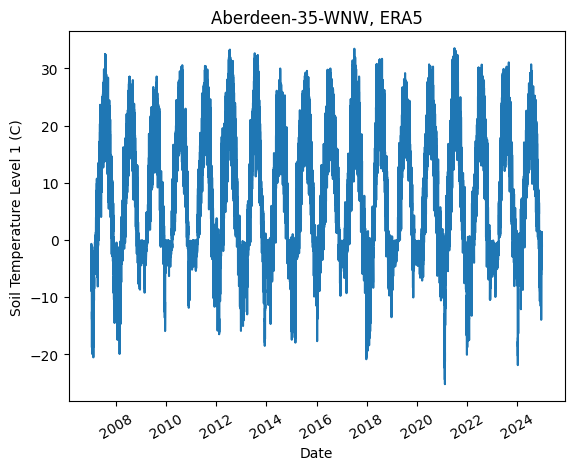

In [9]:
plot(df=ERA5_aberdeen_df, variable=ERA5_short_var_name, y_label=ERA5_long_var_name,
     station=c.ABERDEEN_NAME, system=ERA5, form='line')